# Projeto de Classificação de Textos com Processamento de Linguagem Natural

---

In [1]:
#carregar o arquivo de treino
import gdown
file_id = "1iZt3Ja6vLiTbY7Gf5iFq0spDuyUHrTCC"
url = f"https://drive.google.com/uc?id={file_id}"
output = "train.xlsx"  # nome local no Colab
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1iZt3Ja6vLiTbY7Gf5iFq0spDuyUHrTCC
To: /content/train.xlsx
100%|██████████| 7.62M/7.62M [00:00<00:00, 139MB/s]


'train.xlsx'

### Etapa 1: Análise Exploratória e Limpeza de Dados
*Análise inicial para identificar ruídos, duplicidades e distribuição de classes.*

In [2]:
#analise dos dados
import pandas as pd
df = pd.read_excel("/content/train.xlsx")
print(df.head(10))
print(f"\nQuantidade de dados: {len(df)}")
textos_duplicados = df.groupby('resp_text')['clarity'].nunique()
print(f"Dados repetidos {len(df) - len(textos_duplicados)}")
textos_com_conflito = textos_duplicados[textos_duplicados > 1].index
print(f"Textos com mais de uma classificação: {len(textos_com_conflito)}")
print(f"Quantidade de dados por classe {df['clarity'].value_counts()}")

                                           resp_text clarity
0   Prezado(a) Senhor(a),   Esclarecemos que o Se...      c5
1   Prezada cidadã,  As informações sobre óbitos ...      c1
2   Prezado Senhor Julio,  A Ouvidoria-Geral da P...      c1
3   Prezado(a) Senhor(a),   Esclarecemos que o Se...    c234
4   Senhor, O Serviço de Informações ao Cidadão d...    c234
5   Prezado, para ter acesso às informações solic...      c1
6   Prezado Sr.,  Informamos que a UFPE dispõe de...    c234
7   Prezado (a) Senhor (a),  Em resposta ao seu p...    c234
8   Prezada Angélica,      Anexo encontra-se docu...      c1
9   Prezado Sr. Felipe  Cumprimentando-o cordialm...    c234

Quantidade de dados: 20092
Dados repetidos 1660
Textos com mais de uma classificação: 291
Quantidade de dados por classe clarity
c5      6892
c234    6853
c1      6347
Name: count, dtype: int64


## Estruturação do Split Global Consistente (Prevenção de Data Leakage)
Para evitar que o modelo veja dados de validação na fase de 3 classes que já foram treinados na fase de 2 classes, estabelecemos uma divisão estratificada única de todo o conjunto de dados (3 classes) logo no início.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Carregar a base de dados bruta completa (que contém c1, c234 e c5)
df_bruto = pd.read_excel("/content/train.xlsx")

# 2. Definir o Split Geral Único de forma estratificada
# Isso garante que a proporção das 3 classes seja mantida rigorosamente igual tanto em treino quanto em validação
df_treino_global, df_val_global = train_test_split(
    df_bruto,
    test_size=0.2,
    stratify=df_bruto['clarity'],
    random_state=42
)

print("=== SPLIT GLOBAL CONFIGURADO COM SUCESSO ===")
print(f"Tamanho do Dataset Geral de Treino (80%): {len(df_treino_global)}")
print(f"Tamanho do Dataset Geral de Validação (20%): {len(df_val_global)}")
print(f"\nDistribuição de Classes no Treino:\n{df_treino_global['clarity'].value_counts()}")
print(f"\nDistribuição de Classes na Validação:\n{df_val_global['clarity'].value_counts()}")


=== SPLIT GLOBAL CONFIGURADO COM SUCESSO ===
Tamanho do Dataset Geral de Treino (80%): 16073
Tamanho do Dataset Geral de Validação (20%): 4019

Distribuição de Classes no Treino:
clarity
c5      5513
c234    5482
c1      5078
Name: count, dtype: int64

Distribuição de Classes na Validação:
clarity
c5      1379
c234    1371
c1      1269
Name: count, dtype: int64


In [4]:
import pandas as pd
import re
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.feature_extraction.text import TfidfVectorizer

def remover_saudacoes_iniciais(texto):
    texto = str(texto).strip()

    # Regex robusta:
    # 1. Identifica palavras de saudação comuns no início (prezado, senhor, sr, sra, caro, boa tarde, bom dia, olá, etc.)
    # 2. Ignora o nome ou pronome subsequente até encontrar a primeira vírgula (,) e remove tudo junto.
    padrao_com_virgula = r'^(?:prezad[oa]s?(?:\s*\([ao]\))?|car[oa]s?(?:\s*\([ao]\))?|senhor(?:es|a|as)?(?:\s*\([ao]\))?|sr\.?|sra\.?|car[oa]\b[^,\n]*|boa\s+tarde|bom\s+dia|boa\s+noite|olá)[^,\n]*,\s*'
    texto = re.sub(padrao_com_virgula, '', texto, flags=re.IGNORECASE)

    # Tratamento para casos que usam pontuação espaçada ou sem vírgula no início absoluto (ex: "Senhor.", "Caro Cidadão.")
    padrao_sem_virgula = r'^(?:senhor(?:es|a|as)?|car[oa](?:\s+cidadã[o]?)?|boa\s+tarde|bom\s+dia|boa\s+noite)\b\.?\s*'
    texto = re.sub(padrao_sem_virgula, '', texto, flags=re.IGNORECASE)

    return texto

def limpar_e_tratar_dataset(caminho_arquivo):
    # 1. Carregar os dados
    df_raw = pd.read_excel(caminho_arquivo)
    print(f"Quantidade original de registros: {len(df_raw)}")

    # 2. Remover registros com textos ou rótulos nulos
    df_raw = df_raw.dropna(subset=['resp_text', 'clarity'])
    df_raw['resp_text'] = df_raw['resp_text'].astype(str).str.strip()

    # Aplicar a limpeza de saudações iniciais
    df_raw['resp_text'] = df_raw['resp_text'].apply(remover_saudacoes_iniciais)

    # 3. Limpeza Direcionada: Substituir URLs por '[URL]' e normalizar espaçamentos
    df_raw['resp_text'] = df_raw['resp_text'].apply(lambda x: re.sub(r'https?://\S+', '[URL]', x))
    df_raw['resp_text'] = df_raw['resp_text'].apply(lambda x: re.sub(r'\s+', ' ', x))

    # 4. Manter APENAS as classes c1 e c5 para o treinamento
    df_filtrado = df_raw[df_raw['clarity'].isin(['c1', 'c5'])].copy()
    print(f"Quantidade após filtrar apenas c1 e c5: {len(df_filtrado)}")

    # 5. Identificar e remover ruído de rótulos (textos idênticos com classes diferentes)
    conflitos = df_filtrado.groupby('resp_text')['clarity'].nunique()
    textos_com_conflito = conflitos[conflitos > 1].index
    print(f"Textos com conflito de rótulos (ruído detectado): {len(textos_com_conflito)}")
    df_limpo = df_filtrado[~df_filtrado['resp_text'].isin(textos_com_conflito)].copy()

    # 6. Remover duplicatas consistentes
    antes_dedup = len(df_limpo)
    df_limpo = df_limpo.drop_duplicates(subset=['resp_text'])
    print(f"Duplicatas consistentes removidas: {antes_dedup - len(df_limpo)}")

    # 7. Remoção de Outliers utilizando Isolation Forest (representação por TF-IDF rápido)
    print("Iniciando detecção e remoção de outliers...")
    vectorizer = TfidfVectorizer(max_features=500, stop_words=None)
    tfidf_matrix = vectorizer.fit_transform(df_limpo['resp_text'])

    # Instanciar o Isolation Forest para detectar anomalias (5% de contaminação esperada)
    iso_forest = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
    preds_outliers = iso_forest.fit_predict(tfidf_matrix.toarray())

    # -1 representa outliers, 1 representa dados normais
    antes_outliers = len(df_limpo)
    df_limpo = df_limpo[preds_outliers == 1].copy()
    print(f"Outliers removidos por anomalia semântica/comprimento: {antes_outliers - len(df_limpo)}")

    print(f"Quantidade final de registros para treinamento (c1 e c5): {len(df_limpo)}")
    print("Distribuição das classes pós-tratamento:")
    print(df_limpo['clarity'].value_counts())

    return df_limpo

# Executar o tratamento de dados
df_tratado = limpar_e_tratar_dataset("/content/train.xlsx")
df = df_tratado

Quantidade original de registros: 20092
Quantidade após filtrar apenas c1 e c5: 13239
Textos com conflito de rótulos (ruído detectado): 183
Duplicatas consistentes removidas: 344
Iniciando detecção e remoção de outliers...
Outliers removidos por anomalia semântica/comprimento: 579
Quantidade final de registros para treinamento (c1 e c5): 10984
Distribuição das classes pós-tratamento:
clarity
c5    6009
c1    4975
Name: count, dtype: int64


### Etapa 2: Modelo Baseline (TF-IDF + Regressão Logística)
*Esta célula executa um modelo estatístico básico para servir como baseline de comparação.*

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

# Garantir que estamos utilizando a base limpa e tratada
df_limpo = df_tratado.copy()
df_limpo['resp_text'] = df_limpo['resp_text'].astype(str)

X = df_limpo['resp_text']
Y = df_limpo['clarity']

x_train_text, x_test_text, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=123, stratify=Y
)

# Vetorizador otimizado com restrição de vocabulário para reduzir ruído
vetor = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85,
    max_features=20000
)

x_train = vetor.fit_transform(x_train_text)
x_test = vetor.transform(x_test_text)

# Treinamento da Regressão Logística
clf = LogisticRegression(C=10.0, penalty='l2', solver='liblinear', max_iter=500)
clf.fit(x_train, y_train)

predicted = clf.predict(x_test)
score = f1_score(y_test, predicted, average='macro')
accuracy = accuracy_score(y_test, predicted)

print(f"Vocabulário final (número de features): {len(vetor.vocabulary_)}")
print(f"Acurácia: {accuracy:.4f}")
print(f"F1-score: {score:.4f}")

Vocabulário final (número de features): 20000
Acurácia: 0.6536
F1-score: 0.6491


### Etapa 2.1: Projeção de Embeddings (PCA)
*Representação gráfica bidimensional dos embeddings semânticos dos textos para analisar a separação de classes.*

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/339 [00:00<?, ?it/s]


Variância explicada (2 componentes): 11.71%
  - Componente 1: 6.52%
  - Componente 2: 5.19%


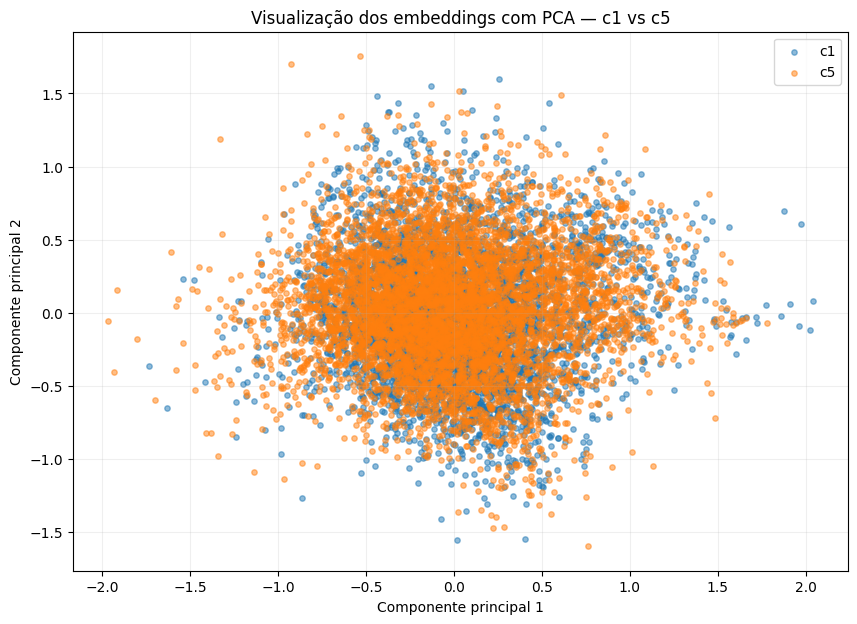

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

# ---------------------------------------------------------------------------
# Configurações
# ---------------------------------------------------------------------------
RANDOM_STATE = 42

MODELO_EMBEDDING = "paraphrase-multilingual-MiniLM-L12-v2"
PALAVRAS_POR_CHUNK = 90   # mesmo valor usado no pipeline original

# Agora uma lista, em vez de duas variáveis fixas
CLASSES = ["c1", "c5"]   # ajuste aqui para as classes que quiser comparar


def dividir_em_chunks(texto, palavras_por_chunk=PALAVRAS_POR_CHUNK):
    """Quebra o texto em pedaços de N palavras, para não estourar o limite do modelo."""
    palavras = texto.split()
    if len(palavras) == 0:
        return [""]
    return [
        " ".join(palavras[i:i + palavras_por_chunk])
        for i in range(0, len(palavras), palavras_por_chunk)
    ]


def embedding_documento_completo(textos, modelo_embedding, batch_size=64):
    """
    Para cada texto: quebra em chunks, embeda cada chunk, e faz a MÉDIA
    dos embeddings dos chunks -> um único vetor representando o texto inteiro.
    """
    todos_chunks = []
    indice_documento = []

    for i, texto in enumerate(textos):
        chunks = dividir_em_chunks(texto)
        todos_chunks.extend(chunks)
        indice_documento.extend([i] * len(chunks))

    embeddings_chunks = modelo_embedding.encode(
        todos_chunks, show_progress_bar=True, batch_size=batch_size
    )

    indice_documento = np.array(indice_documento)
    dim = embeddings_chunks.shape[1]
    embeddings_documento = np.zeros((len(textos), dim), dtype="float32")

    for i in range(len(textos)):
        embeddings_documento[i] = embeddings_chunks[indice_documento == i].mean(axis=0)

    return embeddings_documento


# ---------------------------------------------------------------------------
# 1. Utilizar a base limpa e tratada
# ---------------------------------------------------------------------------
df_usar = df_tratado.copy()
df_usar["resp_text"] = df_usar["resp_text"].astype(str)

x_textos = df_usar["resp_text"].tolist()
y_labels = df_usar["clarity"].tolist()


# ---------------------------------------------------------------------------
# 2. Gerar embeddings
# ---------------------------------------------------------------------------
modelo_embedding = SentenceTransformer(MODELO_EMBEDDING)
x_emb = embedding_documento_completo(x_textos, modelo_embedding)


# ---------------------------------------------------------------------------
# 3. PCA
# ---------------------------------------------------------------------------
pca = PCA(n_components=2, random_state=RANDOM_STATE)
x_pca = pca.fit_transform(x_emb)

print(
    f"\nVariância explicada (2 componentes): "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)
print(f"  - Componente 1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  - Componente 2: {pca.explained_variance_ratio_[1]:.2%}")


# ---------------------------------------------------------------------------
# 4. Visualização
# ---------------------------------------------------------------------------
y_labels_arr = np.array(y_labels)

plt.figure(figsize=(10, 7))

for classe in CLASSES:
    mascara = y_labels_arr == classe
    plt.scatter(
        x_pca[mascara, 0],
        x_pca[mascara, 1],
        label=classe,
        alpha=0.5,
        s=15,
    )

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title(f"Visualização dos embeddings com PCA — {' vs '.join(CLASSES)}")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [ ]:
# ===================================================================
# Etapa 3: Treinamento e Ajuste Fino do Modelo BERTimbau Cased
# ===================================================================
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoConfig,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from torch.utils.data import Dataset

# -------------------------------------------------------------------
# Configurações com Tratamento Ordinal Ajustado e Redução de Overfitting
# -------------------------------------------------------------------
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Definido categoricamente para a versão CASED oficial do Hugging Face
MODELO_BASE = "neuralmind/bert-base-portuguese-cased"
MAX_LENGTH = 384

EPOCHS_FASE1_CONGELADO = 2
EPOCHS_FASE2_DESCONGELADO = 6

BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 2

LEARNING_RATE_FASE1 = 1e-3
LEARNING_RATE_FASE2 = 2e-5

MAPEAMENTO_ORDINAL = {"c1": 1.0, "c234": 3.0, "c5": 5.0}

class ClasseOrdenadora:
    def __init__(self):
        self.classes_ = ["c1", "c234", "c5"]

    def inverse_transform(self, array_labels):
        classes_preditas = []
        for val in array_labels:
            if val < 2.0:
                classes_preditas.append("c1")
            elif val <= 4.0:
                classes_preditas.append("c234")
            else:
                classes_preditas.append("c5")
        return classes_preditas

label_encoder = ClasseOrdenadora()

def carregar_dados():
    global df_tratado
    df_usar = df_tratado.copy()
    x_textos = df_usar['resp_text'].tolist()
    y_valores = df_usar['clarity'].map(MAPEAMENTO_ORDINAL).values.astype(np.float32)
    return x_textos, y_valores

class ClassificacaoDataset(Dataset):
    """Dataset adaptado para Regressão Ordinal com Tail-Truncation."""

    def __init__(self, textos, labels, tokenizer, max_length):
        self.textos = textos
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.textos)

    def __getitem__(self, idx):
        texto = self.textos[idx]
        tokens = self.tokenizer.tokenize(texto)

        if len(tokens) > self.max_length - 2:
            tokens = tokens[-(self.max_length - 2):]

        texto_processado = self.tokenizer.convert_tokens_to_string(tokens)

        encoding = self.tokenizer(
            texto_processado,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.squeeze()

    preds_classes = label_encoder.inverse_transform(predictions)
    labels_classes = label_encoder.inverse_transform(labels)

    return {
        'accuracy': accuracy_score(labels_classes, preds_classes),
        'f1_macro': f1_score(labels_classes, preds_classes, average='macro')
    }

if __name__ == "__main__":
    x_textos, y_valores = carregar_dados()

    x_train, x_val, y_train, y_val = train_test_split(
        x_textos, y_valores, test_size=TEST_SIZE, stratify=y_valores, random_state=RANDOM_STATE
    )

    tokenizer = AutoTokenizer.from_pretrained(
        MODELO_BASE,
        local_files_only=False
    )

    config = AutoConfig.from_pretrained(
        MODELO_BASE,
        num_labels=1,
        hidden_dropout_prob=0.1,
        attention_probs_dropout_prob=0.1,
        classifier_dropout=0.1,
        local_files_only=False
    )
    modelo = AutoModelForSequenceClassification.from_pretrained(
        MODELO_BASE,
        config=config,
        local_files_only=False
    )

    dataset_train = ClassificacaoDataset(x_train, y_train, tokenizer, MAX_LENGTH)
    dataset_val = ClassificacaoDataset(x_val, y_val, tokenizer, MAX_LENGTH)

    # ===================================================================
    # FASE 1: Corpo do BERTimbau Congelado (Apenas cabeça de regressão)
    # ===================================================================
    print("\n--- FASE 1: Congelando o corpo do BERTimbau (Apenas cabeça de regressão) ---")

    for param in modelo.bert.parameters():
        param.requires_grad = False

    training_args_fase1 = TrainingArguments(
        output_dir="./resultados_bert_fase1",
        num_train_epochs=EPOCHS_FASE1_CONGELADO,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        learning_rate=LEARNING_RATE_FASE1,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=100,
        report_to="none"
    )

    trainer_fase1 = Trainer(
        model=modelo,
        args=training_args_fase1,
        train_dataset=dataset_train,
        eval_dataset=dataset_val,
        compute_metrics=compute_metrics
    )

    trainer_fase1.train()

    # ===================================================================
    # FASE 2: Ajuste Fino Completo (Descongelado com Early Stopping)
    # ===================================================================
    print("\n--- FASE 2: Descongelando todo o modelo com Early Stopping ---")

    for param in modelo.bert.parameters():
        param.requires_grad = True

    total_steps_fase2 = (len(dataset_train) // (BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)) * EPOCHS_FASE2_DESCONGELADO
    warmup_steps_fase2 = int(total_steps_fase2 * 0.1)

    training_args_fase2 = TrainingArguments(
        output_dir="./resultados_bert_fase2",
        num_train_epochs=EPOCHS_FASE2_DESCONGELADO,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        learning_rate=LEARNING_RATE_FASE2,
        weight_decay=0.01,
        warmup_steps=warmup_steps_fase2,
        lr_scheduler_type="linear",
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        logging_steps=50,
        report_to="none"
    )

    trainer = Trainer(
        model=modelo,
        args=training_args_fase2,
        train_dataset=dataset_train,
        eval_dataset=dataset_val,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    # 3. Predição e Métricas de Avaliação
    resultado = trainer.predict(dataset_val)

    y_pred_cont = resultado.predictions.squeeze()
    y_pred_classes_str = label_encoder.inverse_transform(y_pred_cont)
    y_val_classes_str = label_encoder.inverse_transform(y_val)

    map_discreto = {"c1": 0, "c234": 1, "c5": 2}
    y_pred_val = np.array([map_discreto[c] for c in y_pred_classes_str])
    y_val_int = np.array([map_discreto[c] for c in y_val_classes_str])

    print(f"\nAccuracy final obtida: {accuracy_score(y_val_classes_str, y_pred_classes_str):.4f}")
    print(f"F1-score (macro) final obtido: {f1_score(y_val_classes_str, y_pred_classes_str, average='macro'):.4f}")

    print("\nMatriz de confusão final:")
    print(f"Classes na ordem: ['c1', 'c234', 'c5']")
    print(confusion_matrix(y_val_int, y_pred_val))

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th


--- FASE 1: Congelando o corpo do BERTimbau (Apenas cabeça de regressão) ---


model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


### Etapa 4: Calibração Dinâmica de Fronteiras de Decisão
*Busca exaustiva de limiares ótimos para otimização pós-regressão baseada na métrica F1-Macro.*

In [ ]:
# Célula antiga desativada para evitar duplicidade de código.
# O código unificado e corrigido com a versão Cased do BERTimbau está localizado na célula abaixo sob o título 'Etapa 3'.

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def otimizar_limiares_f1(y_true_values, y_pred_continuous):
    """
    Realiza uma busca em grade fina para encontrar os dois limiares de corte
    que maximizam o F1-score macro.
    """
    melhor_f1 = 0.0
    melhores_limiares = (2.0, 4.0)  # Ponto de partida padrão

    # Gerar possíveis candidatos a limiares baseados no intervalo prático das predições
    min_pred = max(1.0, float(np.min(y_pred_continuous)))
    max_pred = min(5.0, float(np.max(y_pred_continuous)))

    # Varre faixas plausíveis para os cortes
    candidatos_t1 = np.linspace(min_pred + 0.1, 3.0, 30)
    candidatos_t2 = np.linspace(3.0, max_pred - 0.1, 30)

    for t1 in candidatos_t1:
        for t2 in candidatos_t2:
            if t1 >= t2:
                continue

            # Aplicar limiares candidatos
            preds_temp = []
            for val in y_pred_continuous:
                if val < t1:
                    preds_temp.append("c1")
                elif val <= t2:
                    preds_temp.append("c234")
                else:
                    preds_temp.append("c5")

            # Mapear os labels reais para as strings originais correspondentes (1.0->c1, 3.0->c234, 5.0->c5)
            labels_temp = []
            for label in y_true_values:
                if label == 1.0:
                    labels_temp.append("c1")
                elif label == 3.0:
                    labels_temp.append("c234")
                else:
                    labels_temp.append("c5")

            score = f1_score(labels_temp, preds_temp, average='macro')

            if score > melhor_f1:
                melhor_f1 = score
                melhores_limiares = (t1, t2)

    return melhores_limiares, melhor_f1

# 1. Recuperar predições de regressão contínuas e rótulos reais obtidos pelo Trainer
y_pred_cont = resultado.predictions.squeeze()

# 2. Otimizar os limiares dinamicamente para o F1-macro no set de Validação
(limiar_1, limiar_2), f1_otimizado = otimizar_limiares_f1(y_val, y_pred_cont)

print("=== CALIBRAÇÃO DINÂMICA DE FRONTEIRAS DE DECISÃO ===")
print(f"Limiar Otimizado 1 (c1 -> c234): {limiar_1:.4f} (Anterior: 2.0000)")
print(f"Limiar Otimizado 2 (c234 -> c5): {limiar_2:.4f} (Anterior: 4.0000)")

# 3. Aplicar os novos limiares dinâmicos calibrados
y_pred_otimizado_str = []
for val in y_pred_cont:
    if val < limiar_1:
        y_pred_otimizado_str.append("c1")
    elif val <= limiar_2:
        y_pred_otimizado_str.append("c234")
    else:
        y_pred_otimizado_str.append("c5")

y_val_str = []
for val in y_val:
    if val == 1.0:
        y_val_str.append("c1")
    elif val == 3.0:
        y_val_str.append("c234")
    else:
        y_val_str.append("c5")

# 4. Exibir as novas métricas pós-calibração
acuracia_otimizada = accuracy_score(y_val_str, y_pred_otimizado_str)

print(f"\nNova Acurácia Global Otimizada: {acuracia_otimizada:.4f}")
print(f"Novo F1-Score (Macro) Otimizado: {f1_otimizado:.4f}")

# 5. Nova Matriz de Confusão
map_discreto = {"c1": 0, "c234": 1, "c5": 2}
y_pred_val_int = np.array([map_discreto[c] for c in y_pred_otimizado_str])
y_val_int = np.array([map_discreto[c] for c in y_val_str])

print("\nMatriz de confusão com Limiares Otimizados:")
print("Classes na ordem: ['c1', 'c234', 'c5']")
print(confusion_matrix(y_val_int, y_pred_val_int))

### Etapa 5: Relatório de Classificação e Gráficos de Aprendizado
*Avaliação detalhada com Classification Report e evolução das perdas (Loss) ao longo das etapas.*

In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# 1. Gerar o relatório de classificação detalhado para o BERTimbau
print("=== RELATÓRIO DE CLASSIFICAÇÃO DETALHADO (BERTimbau) ===")
y_pred_classes = label_encoder.inverse_transform(y_pred_val)
y_val_classes = label_encoder.inverse_transform(y_val)
print(classification_report(y_val_classes, y_pred_classes))

# 2. Verificar o histórico de perda (loss) se gravado no Trainer
try:
    historico = trainer.state.log_history
    passos_treino = [log for log in historico if 'loss' in log]
    passos_eval = [log for log in historico if 'eval_loss' in log]

    if passos_treino:
        df_loss_treino = pd.DataFrame(passos_treino)
        plt.figure(figsize=(10, 4))
        plt.plot(df_loss_treino['step'], df_loss_treino['loss'], label='Perda no Treino (Loss)', color='blue')
        if 'eval_loss' in pd.DataFrame(passos_eval).columns:
            df_loss_eval = pd.DataFrame(passos_eval)
            plt.plot(df_loss_eval['step'], df_loss_eval['eval_loss'], label='Perda na Validação (Eval Loss)', color='orange', marker='o')
        plt.title('Curva de Aprendizado do BERTimbau')
        plt.xlabel('Passos de Treino (Steps)')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()
    else:
        print("Sem logs de treino detalhados para exibir o gráfico de perda.")
except Exception as e:
    print(f"Não foi possível carregar os gráficos de perda: {e}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extrair e estruturar o histórico de logs do Trainer
log_history = trainer.state.log_history

treino_logs = []
eval_logs = []

for log in log_history:
    if 'loss' in log:
        treino_logs.append({
            'step': log['step'],
            'epoch': log['epoch'],
            'train_loss': log['loss']
        })
    if 'eval_loss' in log:
        eval_logs.append({
            'step': log['step'],
            'epoch': log['epoch'],
            'eval_loss': log['eval_loss'],
            'eval_accuracy': log.get('eval_accuracy', None),
            'eval_f1_macro': log.get('eval_f1_macro', None)
        })

df_treino = pd.DataFrame(treino_logs)
df_eval = pd.DataFrame(eval_logs)

# Exibir os logs em tabelas para análise numérica detalhada
print("=== HISTÓRICO DE TREINAMENTO (TREINO) ===")
display(df_treino)
print("\n=== HISTÓRICO DE AVALIAÇÃO (VALIDAÇÃO) ===")
display(df_eval)

# 2. Plotar as Curvas de Aprendizado (Loss e Métricas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Perda (Loss)
if not df_treino.empty:
    ax1.plot(df_treino['step'], df_treino['train_loss'], label='Perda no Treino', color='blue', marker='o')
if not df_eval.empty:
    ax1.plot(df_eval['step'], df_eval['eval_loss'], label='Perda na Validação', color='orange', marker='s')
ax1.set_title('Curvas de Perda (Loss)')
ax1.set_xlabel('Passos (Steps)')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Gráfico de Acurácia e F1-Score na Validação
if not df_eval.empty and 'eval_accuracy' in df_eval.columns:
    ax2.plot(df_eval['step'], df_eval['eval_accuracy'], label='Acurácia Validação', color='green', marker='^')
    ax2.plot(df_eval['step'], df_eval['eval_f1_macro'], label='F1 Macro Validação', color='red', marker='v')
ax2.set_title('Métricas de Validação ao Longo do Treino')
ax2.set_xlabel('Passos (Steps)')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Nova Etapa: Treinamento e Teste Incluindo a Classe `c234`

Nesta etapa, ajustamos a função de preparação para manter as três classes (`c1`, `c234`, `c5`). O modelo BERTimbau aprenderá a mapear os textos de forma contínua entre 1.0 e 5.0, utilizando a classe `c234` (3.0) como uma barreira natural para afastar e separar melhor os extremos `c1` (1.0) e `c5` (5.0).

In [ ]:
import pandas as pd
import re
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import IsolationForest

def limpar_e_tratar_dataset_com_c234(caminho_arquivo):
    df_raw = pd.read_excel(caminho_arquivo)
    print(f"Quantidade original de registros: {len(df_raw)}")

    df_raw = df_raw.dropna(subset=['resp_text', 'clarity'])
    df_raw['resp_text'] = df_raw['resp_text'].astype(str).str.strip()
    df_raw['resp_text'] = df_raw['resp_text'].apply(remover_saudacoes_iniciais)

    df_raw['resp_text'] = df_raw['resp_text'].apply(lambda x: re.sub(r'https?://\S+', '[URL]', x))
    df_raw['resp_text'] = df_raw['resp_text'].apply(lambda x: re.sub(r'\s+', ' ', x))

    # MANTER AS TRÊS CLASSES: c1, c234 e c5
    df_filtrado = df_raw[df_raw['clarity'].isin(['c1', 'c234', 'c5'])].copy()
    print(f"Quantidade após filtrar c1, c234 e c5: {len(df_filtrado)}")

    conflitos = df_filtrado.groupby('resp_text')['clarity'].nunique()
    textos_com_conflito = conflitos[conflitos > 1].index
    df_limpo = df_filtrado[~df_filtrado['resp_text'].isin(textos_com_conflito)].copy()

    df_limpo = df_limpo.drop_duplicates(subset=['resp_text'])

    # Remover outliers
    vectorizer = TfidfVectorizer(max_features=500, stop_words=None)
    tfidf_matrix = vectorizer.fit_transform(df_limpo['resp_text'])
    iso_forest = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
    preds_outliers = iso_forest.fit_predict(tfidf_matrix.toarray())
    df_limpo = df_limpo[preds_outliers == 1].copy()

    print(f"Quantidade final para treinamento com as 3 classes: {len(df_limpo)}")
    print(df_limpo['clarity'].value_counts())
    return df_limpo

# Gerar o novo dataset
df_tres_classes = limpar_e_tratar_dataset_com_c234("/content/train.xlsx")

In [ ]:
import torch
import numpy as np
import os
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig, TrainingArguments, Trainer, EarlyStoppingCallback

# Preparar dados com as 3 classes
x_textos_3 = df_tres_classes['resp_text'].tolist()
y_valores_3 = df_tres_classes['clarity'].map(MAPEAMENTO_ORDINAL).values.astype(np.float32)

x_train_3, x_val_3, y_train_3, y_val_3 = train_test_split(
    x_textos_3, y_valores_3, test_size=TEST_SIZE, stratify=y_valores_3, random_state=RANDOM_STATE
)

dataset_train_3 = ClassificacaoDataset(x_train_3, y_train_3, tokenizer, MAX_LENGTH)
dataset_val_3 = ClassificacaoDataset(x_val_3, y_val_3, tokenizer, MAX_LENGTH)

# Determinar o melhor checkpoint do primeiro treinamento (Fase 2)
pasta_fase2 = "./resultados_bert_fase2"
if os.path.exists(pasta_fase2):
    checkpoints = [os.path.join(pasta_fase2, d) for d in os.listdir(pasta_fase2) if d.startswith("checkpoint-")]
    if checkpoints:
        # Carrega o checkpoint mais recente ou configurado como melhor
        CAMINHO_HERANCA = max(checkpoints, key=os.path.getmtime)
        print(f"Herdando pesos do primeiro treinamento a partir de: {CAMINHO_HERANCA}")
    else:
        CAMINHO_HERANCA = MODELO_BASE
        print(f"Nenhum checkpoint encontrado em {pasta_fase2}. Iniciando do modelo base original.")
else:
    CAMINHO_HERANCA = MODELO_BASE
    print(f"Pasta {pasta_fase2} não encontrada. Iniciando do modelo base original.")

# Carregar o modelo herdando o aprendizado anterior
modelo_3 = AutoModelForSequenceClassification.from_pretrained(
    CAMINHO_HERANCA,
    num_labels=1,
    ignore_mismatched_sizes=True
)

# Ajuste Fino otimizado para maximizar a acurácia - Aumentado de 8 para 12 épocas
EPOCHS_3 = 12
total_steps_3 = (len(dataset_train_3) // (BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)) * EPOCHS_3
warmup_steps_3 = int(total_steps_3 * 0.1)

training_args_3 = TrainingArguments(
    output_dir="./resultados_bert_3classes",
    num_train_epochs=EPOCHS_3,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=1.5e-5,
    weight_decay=0.01,
    warmup_steps=warmup_steps_3,
    lr_scheduler_type="linear",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=100,
    report_to="none"
)

trainer_3 = Trainer(
    model=modelo_3,
    args=training_args_3,
    train_dataset=dataset_train_3,
    eval_dataset=dataset_val_3,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("\n--- Iniciando Treinamento Otimizado com c1, c234 e c5 (com Herança de Pesos) ---")
trainer_3.train()

In [ ]:
# Avaliação e Calibração Dinâmica pós-treino com as 3 classes
resultados_3 = trainer_3.predict(dataset_val_3)
y_pred_cont_3 = resultados_3.predictions.squeeze()

(limiar_1_3, limiar_2_3), f1_otimizado_3 = otimizar_limiares_f1(y_val_3, y_pred_cont_3)

print("=== NOVOS LIMIARES CALIBRADOS (3 CLASSES) ===")
print(f"Limiar Otimizado 1 (c1 -> c234): {limiar_1_3:.4f}")
print(f"Limiar Otimizado 2 (c234 -> c5): {limiar_2_3:.4f}")
print(f"F1-Score (Macro) Otimizado: {f1_otimizado_3:.4f}")

# Aplicar predição final
y_pred_final_str = []
for val in y_pred_cont_3:
    if val < limiar_1_3:
        y_pred_final_str.append("c1")
    elif val <= limiar_2_3:
        y_pred_final_str.append("c234")
    else:
        y_pred_final_str.append("c5")

y_val_final_str = []
for val in y_val_3:
    if val == 1.0:
        y_val_final_str.append("c1")
    elif val == 3.0:
        y_val_final_str.append("c234")
    else:
        y_val_final_str.append("c5")

print("\nMatriz de Confusão Otimizada com as 3 Classes:")
print(confusion_matrix(y_val_final_str, y_pred_final_str, labels=["c1", "c234", "c5"]))
print("\nRelatório de Classificação Final:")
print(classification_report(y_val_final_str, y_pred_final_str))